# IoD Analysis Notebook
Index of Dispersion analysis across thresholds, chromosomes, and populations.
Masel Lab — Spencer Hatcher

**Usage:** Set the paths and parameters in the Configuration cell, then run all cells.

In [1]:
import pickle
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

## Configuration
Edit these paths and parameters before running.

In [3]:
# ── Paths ──────────────────────────────────────────────────────────────────
# Directory containing chrN_individuals.pkl files
# Change this to the HPC path when running on Puma:
OUTPUT_DIR = "/groups/masel/spencer_pai3d/output"
# OUTPUT_DIR = "/home/shatcher1/projects/PrimateAI-3D/pipeline/output"

# Path to pipeline directory (for importing Individual class)
# Change to HPC path when running on Puma:
PIPELINE_DIR = "/groups/masel/spencer_pai3d/pipeline/pipeline"
# PIPELINE_DIR = "/home/shatcher1/projects/PrimateAI-3D/pipeline"

# ── Chromosomes to include ─────────────────────────────────────────────────
# Change to list(range(1, 23)) when all 22 pickles are available
CHROMOSOMES = list(range(1, 23))

# ── Threshold range ────────────────────────────────────────────────────────
# Start, stop (exclusive), step
THRESHOLD_START = 0.5
THRESHOLD_STOP  = 1.0
THRESHOLD_STEP  = 0.05

thresholds = list(np.arange(THRESHOLD_START, THRESHOLD_STOP, THRESHOLD_STEP))
thresholds = [round(t, 4) for t in thresholds]

print(f"Chromosomes: {CHROMOSOMES}")
print(f"Thresholds:  {thresholds}")

Chromosomes: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22]
Thresholds:  [0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95]


## Load Individual objects

In [9]:
sys.path.append(PIPELINE_DIR)
from individual import Individual

# load pickle files for each chromosome
# key: chromosome number, value: list of Individual objects
individuals_by_chr = {}

for chr_num in CHROMOSOMES:
    pkl_path = os.path.join(OUTPUT_DIR, f"chr{chr_num}_individuals.pkl")
    if not os.path.exists(pkl_path):
        print(f"WARNING: {pkl_path} not found, skipping chr{chr_num}")
        continue
    with open(pkl_path, "rb") as f:
        individuals_by_chr[chr_num] = pickle.load(f)
    print(f"Loaded chr{chr_num}: {len(individuals_by_chr[chr_num])} individuals")

print(f"\nTotal chromosomes loaded: {len(individuals_by_chr)}")

# merge individuals across chromosomes by sample_id
# each person appears in every chromosome pickle separately
# we combine their variant lists so each person appears once with all variants
merged_individuals = {}

for chr_num in individuals_by_chr:
    for ind in individuals_by_chr[chr_num]:
        if ind.sample_id not in merged_individuals:
            merged_individuals[ind.sample_id] = ind
        else:
            for variant in ind.variants:
                merged_individuals[ind.sample_id].add_variant(variant)

# convert to list for downstream analysis
all_individuals = list(merged_individuals.values())

print(f"Total unique individuals after merge: {len(all_individuals)}")

Loaded chr1: 3202 individuals
Loaded chr2: 3202 individuals
Loaded chr3: 3202 individuals
Loaded chr4: 3202 individuals
Loaded chr5: 3202 individuals
Loaded chr6: 3202 individuals
Loaded chr7: 3202 individuals
Loaded chr8: 3202 individuals
Loaded chr9: 3202 individuals
Loaded chr10: 3202 individuals
Loaded chr11: 3202 individuals
Loaded chr12: 3202 individuals
Loaded chr13: 3202 individuals
Loaded chr14: 3202 individuals
Loaded chr15: 3202 individuals
Loaded chr16: 3202 individuals
Loaded chr17: 3202 individuals
Loaded chr18: 3202 individuals
Loaded chr19: 3202 individuals
Loaded chr20: 3202 individuals
Loaded chr21: 3202 individuals
Loaded chr22: 3202 individuals

Total chromosomes loaded: 22
Total unique individuals after merge: 3202


## IoD Table — varies threshold
Computes pathogenic and benign IoD at each threshold across all loaded chromosomes combined.

In [10]:
def compute_iod(individuals, threshold):
    # computes variance/mean ratio (index of dispersion) for a list of Individual objects
    # returns dict with pathogenic and benign IoD values
    pathogenic_burdens = []
    benign_burdens = []

    for ind in individuals:
        burden = ind.compute_burden(threshold)
        pathogenic_burdens.append(burden["pathogenic"])
        benign_burdens.append(burden["benign"])

    pathogenic_burdens = np.array(pathogenic_burdens)
    benign_burdens = np.array(benign_burdens)

    pathogenic_iod = np.var(pathogenic_burdens, ddof=1) / np.mean(pathogenic_burdens)
    benign_iod = np.var(benign_burdens, ddof=1) / np.mean(benign_burdens)

    return {"pathogenic": pathogenic_iod, "benign": benign_iod}


# merge all individuals across chromosomes into one flat list
# NOTE: when multiple chromosomes are loaded, individuals share sample IDs
# across chromosomes this merges them
all_individuals = []
for chr_num in individuals_by_chr:
    for ind in individuals_by_chr[chr_num]:
        all_individuals.append(ind)

# compute IoD at each threshold
threshold_rows = []

for threshold in thresholds:
    result = compute_iod(all_individuals, threshold)
    threshold_rows.append({
        "threshold": threshold,
        "pathogenic_iod": round(result["pathogenic"], 4),
        "benign_iod": round(result["benign"], 4)
    })

threshold_df = pd.DataFrame(threshold_rows)
print(threshold_df.to_string(index=False))

 threshold  pathogenic_iod  benign_iod
      0.50        756.3094   5516.5240
      0.55        544.3309   5728.5234
      0.60        371.9659   5900.4112
      0.65        244.3904   6027.7943
      0.70        152.5896   6119.1730
      0.75         91.8285   6179.7020
      0.80         54.0677   6217.4600
      0.85         24.8205   6246.7039
      0.90         11.1805   6259.9688
      0.95          3.2075   6267.8560


## Plot — IoD as a function of threshold

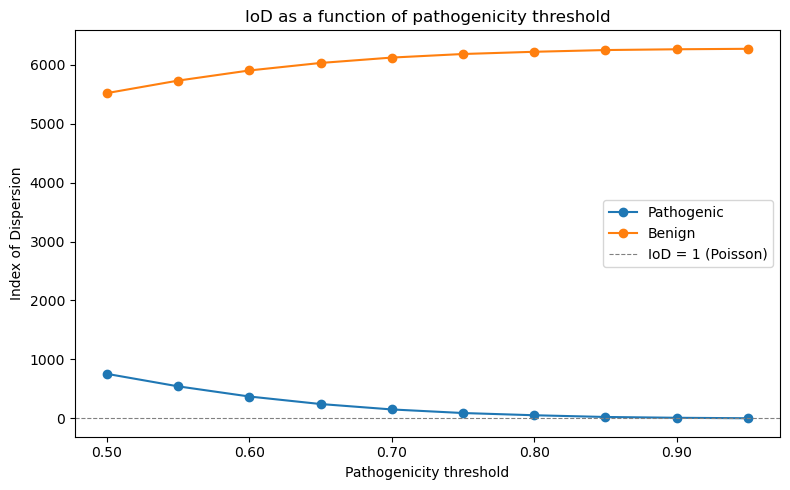

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(threshold_df["threshold"], threshold_df["pathogenic_iod"], marker="o", label="Pathogenic")
ax.plot(threshold_df["threshold"], threshold_df["benign_iod"], marker="o", label="Benign")

ax.axhline(y=1, color="gray", linestyle="--", linewidth=0.8, label="IoD = 1 (Poisson)")
ax.set_xlabel("Pathogenicity threshold")
ax.set_ylabel("Index of Dispersion")
ax.set_title("IoD as a function of pathogenicity threshold")
ax.legend()
ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))

plt.tight_layout()
plt.show()

# Plot - IoD by Chromosome (threshold = 0.821)

In [24]:
DEFAULT_THRESHOLD = 0.821

chr_rows = []

for chr_num in sorted(individuals_by_chr.keys()):
    result = compute_iod(individuals_by_chr[chr_num], DEFAULT_THRESHOLD)
    chr_rows.append({
        "chromosome": chr_num,
        "pathogenic_iod": round(result["pathogenic"], 4),
        "benign_iod": round(result["benign"], 4)
    })


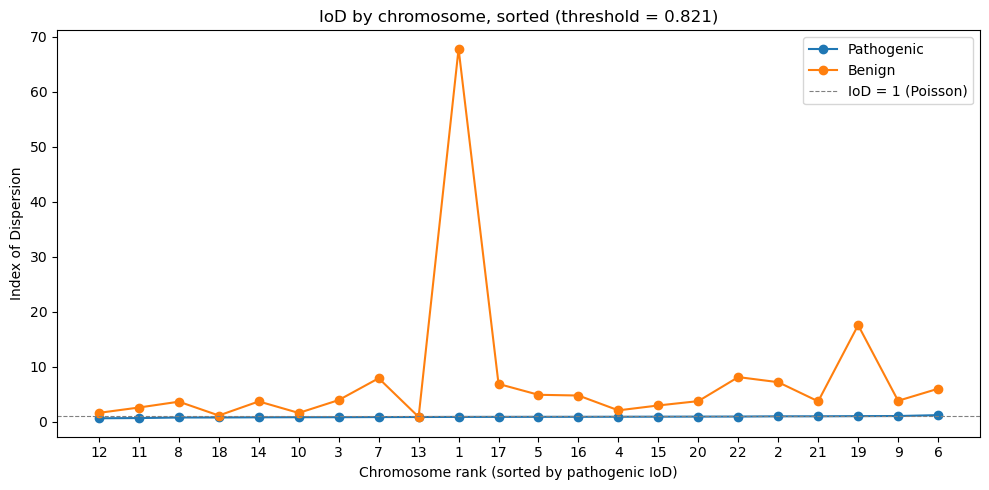

In [26]:
chr_df_sorted = chr_df.sort_values("pathogenic_iod").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(range(1, len(chr_df_sorted) + 1),
        chr_df_sorted["pathogenic_iod"],
        marker="o",
        label="Pathogenic") 

ax.plot(range(1, len(chr_df_sorted) + 1),
        chr_df_sorted["benign_iod"],
        marker = "o",
        label = "Benign")


ax.axhline(y=1, color="gray", linestyle="--", linewidth=0.8, label="IoD = 1 (Poisson)")
ax.set_xlabel("Chromosome rank (sorted by pathogenic IoD)")
ax.set_ylabel("Index of Dispersion")
ax.set_title(f"IoD by chromosome, sorted (threshold = {DEFAULT_THRESHOLD})")
ax.set_xticks(range(1, len(chr_df_sorted) + 1))
ax.set_xticklabels(chr_df_sorted["chromosome"])
ax.legend()

plt.tight_layout()
plt.show()

In [17]:
chr_df.sort_values('pathogenic_iod')

,chromosome,pathogenic_iod,benign_iod
11,12,0.6492,1.6311
10,11,0.6835,2.5988
7,8,0.7863,3.6615
17,18,0.7905,1.1477
13,14,0.8201,3.7072
9,10,0.8354,1.6136
2,3,0.8398,3.9513
6,7,0.8633,7.9183
12,13,0.8736,0.8885
0,1,0.8916,67.7982


## Plot — IoD as a function of population
Uses the PAI3D default threshold (0.821) and all loaded chromosomes combined.

Populations found: ['ACB', 'ASW', 'BEB', 'CDX', 'CEU', 'CHB', 'CHS', 'CLM', 'ESN', 'FIN', 'GBR', 'GIH', 'GWD', 'IBS', 'ITU', 'JPT', 'KHV', 'LWK', 'MSL', 'MXL', 'PEL', 'PJL', 'PUR', 'STU', 'TSI', 'YRI']
population    n  pathogenic_iod  benign_iod
       ACB 2552          2.7395    173.0768
       ASW 1628          2.7896    169.3494
       BEB 2882          2.6648    154.8472
       CDX 2046          2.7965    159.6412
       CEU 3938          2.5817    150.6269
       CHB 2266          2.7618    158.8539
       CHS 3586          2.8991    159.0770
       CLM 2904          2.6609    155.1377
       ESN 3278          2.5954    175.5386
       FIN 2178          2.5039    154.8700
       GBR 2002          2.7068    150.5646
       GIH 2266          2.7622    155.1881
       GWD 3916          2.7717    173.4643
       IBS 3454          2.5889    150.5581
       ITU 2354          2.8249    155.4587
       JPT 2288          2.9015    159.8112
       KHV 2684          2.8401    158.2933
      

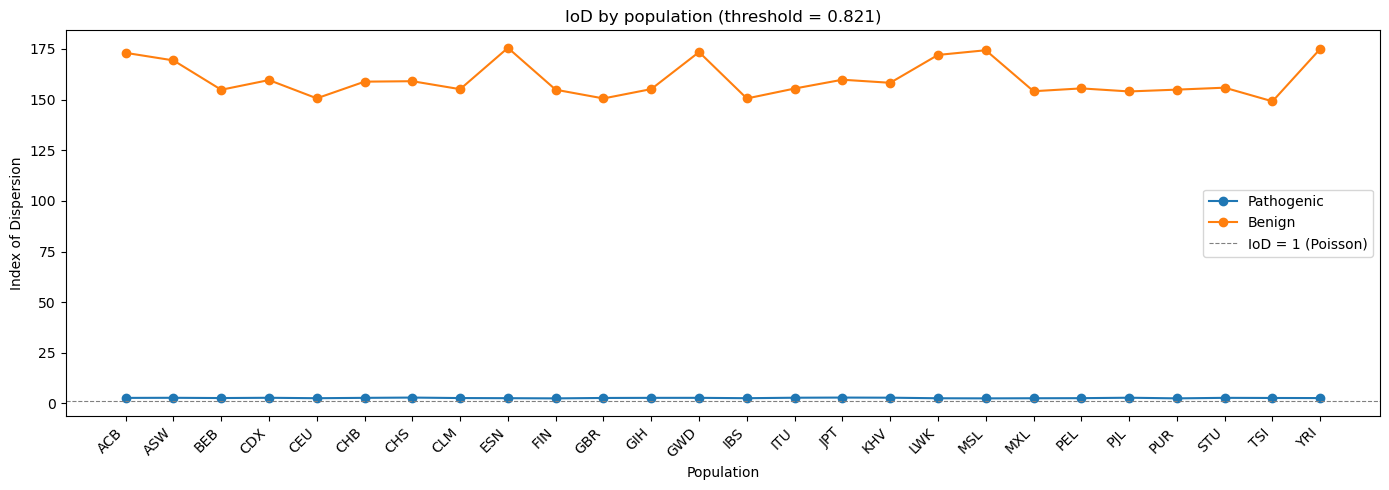

In [8]:
# get all unique population labels from the loaded individuals
populations = set()
for ind in all_individuals:
    if ind.population is not None:
        populations.add(ind.population)

populations = sorted(populations)
print(f"Populations found: {populations}")

pop_rows = []

for population in populations:
    # filter to individuals from this population
    filtered = []
    for ind in all_individuals:
        if ind.population == population:
            filtered.append(ind)

    result = compute_iod(filtered, DEFAULT_THRESHOLD)
    pop_rows.append({
        "population": population,
        "n": len(filtered),
        "pathogenic_iod": round(result["pathogenic"], 4),
        "benign_iod": round(result["benign"], 4)
    })

pop_df = pd.DataFrame(pop_rows)
print(pop_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(14, 5))

x = range(len(pop_df))
ax.plot(x, pop_df["pathogenic_iod"], marker="o", label="Pathogenic")
ax.plot(x, pop_df["benign_iod"], marker="o", label="Benign")

ax.axhline(y=1, color="gray", linestyle="--", linewidth=0.8, label="IoD = 1 (Poisson)")
ax.set_xlabel("Population")
ax.set_ylabel("Index of Dispersion")
ax.set_title(f"IoD by population (threshold = {DEFAULT_THRESHOLD})")
ax.set_xticks(x)
ax.set_xticklabels(pop_df["population"], rotation=45, ha="right")
ax.legend()

plt.tight_layout()
plt.show()